In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
assets = ['PG', '^GSPC']
pf_data = pd.read_csv('Markowitz_Data.csv', index_col = 'Date')

In [4]:
pf_data.head()

,PG,^GSPC
Date,,
2010-01-04,61.119999,1132.989990
2010-01-05,61.139999,1136.520020
2010-01-06,60.849998,1137.140015
2010-01-07,60.520000,1141.689941
2010-01-08,60.439999,1144.979980


In [5]:
pf_data.tail()

,PG,^GSPC
Date,,
2017-03-20,91.220001,2373.469971
2017-03-21,91.190002,2344.020020
2017-03-22,90.989998,2348.449951
2017-03-23,90.769997,2345.959961
2017-03-24,90.570000,2343.979980


<AxesSubplot:xlabel='Date'>

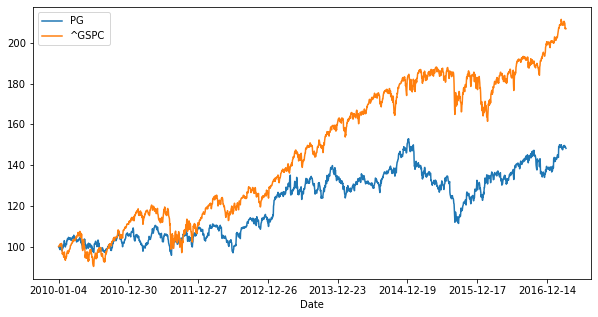

In [6]:
(pf_data / pf_data.iloc[0] * 100).plot(figsize=(10, 5))

In [7]:
log_returns = np.log(pf_data / pf_data.shift(1))

In [8]:
log_returns.mean() * 250

PG       0.054082
^GSPC    0.099971
dtype: float64

In [9]:
log_returns.cov() * 250

,PG,^GSPC
PG,0.02048,0.012490
^GSPC,0.01249,0.023401


In [10]:
log_returns.corr()

,PG,^GSPC
PG,1.000000,0.570527
^GSPC,0.570527,1.000000


In [11]:
num_assets = len(assets)

In [12]:
num_assets

2

In [13]:
arr = np.random.random(2)
arr

array([0.4424985 , 0.62730393])

In [14]:
arr[0] + arr[1]

1.0698024299517956

In [15]:
weights = np.random.random(num_assets)
weights /= np.sum(weights)
weights

array([0.11157336, 0.88842664])

In [16]:
weights[0] + weights[1]

1.0

Expected Portfolio Return:

In [17]:
np.sum(weights * log_returns.mean()) * 250

0.09485113482445867

Expected Portfolio Variance:

In [18]:
np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))

0.021201400635187932

Expected Portfolio Volatility:

In [19]:
np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights)))

0.1456070075071524

***

In [20]:
pfolio_returns = []
pfolio_volatilities = []

for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pfolio_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))

pfolio_returns, pfolio_volatilities

([0.07696122662397753,
  0.07050224338739582,
  0.09391711573652971,
  0.09053682939348073,
  0.07863428696874716,
  0.08442691647377552,
  0.07655858299136943,
  0.0578414898584227,
  0.07691766756382236,
  0.06915414254580014,
  0.09603840240769267,
  0.07960584866794682,
  0.07218345113363021,
  0.07634350051343074,
  0.06525492360113685,
  0.086329683175508,
  0.07662316464651911,
  0.09430184368978678,
  0.0793345424912981,
  0.061300913758153504,
  0.07133118303833928,
  0.06309771635530387,
  0.08266978641353895,
  0.06801261595810701,
  0.07813753791423031,
  0.08841029364229312,
  0.0586256727363232,
  0.0771299500264291,
  0.06965909454294848,
  0.07692261396630602,
  0.06866749743249231,
  0.08356188143752473,
  0.07519487466461444,
  0.09398475486811338,
  0.07613941348085801,
  0.06171705014284378,
  0.06358426410594073,
  0.09686719125980174,
  0.08860274248011503,
  0.06636913987319225,
  0.07165256989097855,
  0.08700977341720274,
  0.06880281470069015,
  0.070671137889

In [21]:
pfolio_returns = []
pfolio_volatilities = []

for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pfolio_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))
    
pfolio_returns = np.array(pfolio_returns)
pfolio_volatilities = np.array(pfolio_volatilities)

pfolio_returns, pfolio_volatilities

(array([0.05624891, 0.07156108, 0.0833905 , 0.081405  , 0.07395347,
        0.0629372 , 0.06546267, 0.07373584, 0.06771026, 0.07177459,
        0.07882553, 0.09675299, 0.07276086, 0.05451945, 0.09885594,
        0.08966341, 0.06860032, 0.0671926 , 0.07977004, 0.07718484,
        0.05644896, 0.072872  , 0.08057373, 0.07241285, 0.08486511,
        0.08643275, 0.07259285, 0.08674939, 0.06059228, 0.07496735,
        0.07514708, 0.07413762, 0.05861069, 0.05837643, 0.07727023,
        0.08254992, 0.08618173, 0.08218197, 0.08672327, 0.07424606,
        0.06756169, 0.06322813, 0.07755489, 0.07717113, 0.08695052,
        0.08229762, 0.06737687, 0.08643305, 0.0779847 , 0.06166722,
        0.07691265, 0.08661308, 0.09248367, 0.07337517, 0.06878764,
        0.0782526 , 0.06922334, 0.09121425, 0.08463504, 0.07773239,
        0.06116427, 0.09845811, 0.07139715, 0.08596763, 0.07199775,
        0.05871584, 0.06050556, 0.08182928, 0.06203065, 0.05716277,
        0.06921377, 0.08948251, 0.08587638, 0.07

In [22]:
portfolios = pd.DataFrame({'Return': pfolio_returns, 'Volatility': pfolio_volatilities})

In [23]:
portfolios.head()

,Return,Volatility
0,0.056249,0.140597
1,0.071561,0.130902
2,0.083390,0.134103
3,0.081405,0.132913
4,0.073953,0.130783


In [24]:
portfolios.tail()

,Return,Volatility
995,0.075061,0.130861
996,0.068704,0.131556
997,0.055329,0.141632
998,0.098462,0.150677
999,0.089077,0.138873


Text(0, 0.5, 'Expected Return')

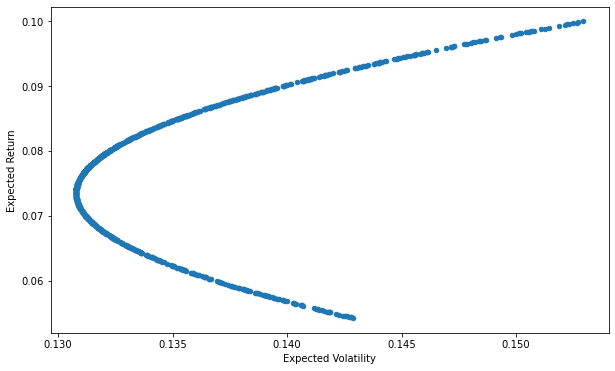

In [25]:
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10, 6));
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')